# SU(2) Adjoint-Sector Ground State Benchmark

This notebook is a reader for results produced by local Python scripts. It does **not** train the neural network and does **not** run validation tests. Generate the data from the repository root with

```bash
python scripts/run_su2_adjoint_benchmarks.py --output results/su2_adjoint_benchmarks.json
```

and run the unit tests separately with

```bash
python -m pytest tests/test_su2_adjoint.py -q
```

The implemented model is the one-matrix SU(2) adjoint sector with

$$
H=-\frac12\Delta_X+\frac12\omega^2\operatorname{Tr}X^2+g\operatorname{Tr}X^4,
\qquad \operatorname{Tr}(T^aT^b)=\delta^{ab}.
$$

The spectral ansatz is

$$
q_i(\lambda)=\exp[-S_\theta(\lambda)/2] \, \lambda_i,
\qquad
S_\theta(\lambda)=\alpha\sum_i\lambda_i^2+f_\theta\!\left(\sum_i\lambda_i^2\right),
$$

so tracelessness, Weyl covariance, odd parity, and SU(2) adjoint covariance are built into the wavefunction before training.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt

ROOT = Path.cwd()
if not (ROOT / "scripts").exists():
    ROOT = ROOT.parent

RESULT_PATH = ROOT / "results" / "su2_adjoint_benchmarks.json"
SU3_RESULT_PATH = ROOT / "results" / "su3_adjoint_benchmarks.json"
{"su2": RESULT_PATH, "su3": SU3_RESULT_PATH}


{'su2': PosixPath('/Users/sam/Documents/research/Adjoint-QM/results/su2_adjoint_benchmarks.json'),
 'su3': PosixPath('/Users/sam/Documents/research/Adjoint-QM/results/su3_adjoint_benchmarks.json')}

## Load Saved Results

The result file is produced by `scripts/run_su2_adjoint_benchmarks.py`. If this cell fails, rerun that script from the repository root. Keeping the training in a script makes the numerical calculation reproducible and keeps this notebook as an inspection layer.

In [2]:
if not RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing benchmark result file. Run from the repository root:\n"
        f"python scripts/run_su2_adjoint_benchmarks.py --output {RESULT_PATH}"
    )

results = json.loads(RESULT_PATH.read_text())
results["metadata"]

{'model': 'one-matrix SU(2) adjoint sector',
 'hamiltonian': '-1/2 Delta_X + 1/2 omega^2 Tr X^2 + g Tr X^4',
 'generator_normalization': 'Tr(T^a T^b)=delta^{ab}',
 'seed': 2027,
 'omega': 1.0,
 'z_max': 8.0,
 'n_grid': 3000,
 'learning_rate': 0.01,
 'report_every': 100,
 'fd_grid': 1600,
 'fd_r_max': 9.0}

## Validation Summary

These booleans are saved by the Python benchmark runner. The actual unit tests live in `tests/test_su2_adjoint.py`; the notebook only displays which checks were used and whether the saved run passed its script-level thresholds.

In [3]:
results["validation_summary"]

{'all_checks_passed': True,
 'checks': {'exact_harmonic_energy_error_lt_1e-10': True,
  'harmonic_training_energy_error_lt_5e-4': True,
  'quartic_training_energy_error_lt_5e-5': True,
  'traceless_residual_lt_1e-12': True,
  'odd_parity_residual_lt_1e-12': True,
  'weyl_covariance_residual_lt_1e-12': True,
  'head_collision_residual_lt_1e-12': True,
  'profile_collision_residual_lt_1e-10': True,
  'so3_covariance_residual_lt_1e-12': True,
  'quartic_radial_overlap_gt_0.9999': True,
  'quartic_radial_l2_difference_lt_0.02': True,
  'quartic_r2_moment_error_lt_0.005': True,
  'quartic_r4_moment_error_lt_0.03': True,
  'quartic_virial_residual_lt_0.002': True,
  'quartic_hellmann_feynman_error_lt_0.002': True,
  'quartic_schrodinger_residual_lt_0.05': True},
 'unit_test_command': 'python -m pytest tests/test_su2_adjoint.py -q',
 'full_test_command': 'python -m pytest -q',
 'unit_test_file': 'tests/test_su2_adjoint.py',
 'unit_tests': ['test_traceless_hyperplane_basis_is_orthonormal',
  '

## Exact Harmonic Benchmark

For `g=0`, the exact lowest adjoint-sector energy is

$$
E_{\rm adj,0}=\frac{\omega}{2}(N^2-1)+\omega,
$$

so for SU(2) and \(\omega=1\), the target is \(E=5/2\). This is the strongest convention check because it tests the Vandermonde weight, angular term, and adjoint head normalization.

In [ ]:
results["exact_harmonic"]["observables"]

## Harmonic Training History

This plot shows the script-run optimization from an intentionally wrong Gaussian envelope. The y-axis is \(\log_{10}|E_\theta-E_{\rm exact}|\), so lower is better. The exact harmonic check above is the real exactness test; this plot checks that optimization moves the ansatz toward that result.

In [ ]:
def log10_abs(values, floor=1.0e-16):
    return [math.log10(max(abs(value), floor)) for value in values]

harmonic_history = results["harmonic_training"]["history"]
harmonic_steps = [record["step"] for record in harmonic_history]
harmonic_errors = [record["energy_error"] for record in harmonic_history]

plt.figure(figsize=(6, 4))
plt.plot(harmonic_steps, log10_abs(harmonic_errors), marker="o")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm exact}|$")
plt.title("SU(2) adjoint harmonic training")
plt.grid(alpha=0.25)
plt.show()

results["harmonic_training"]["observables"]

## Symmetry Diagnostics

The following residuals are computed in the Python benchmark runner. They check tracelessness, odd parity under \(X\to -X\), Weyl covariance under eigenvalue exchange, and SO(3) covariance of the SU(2) component wavefunction.

In [ ]:
results["symmetry_checks"]

## Quartic Benchmark

For `g=0.05`, there is no closed-form answer. In SU(2), the problem is independently reducible to the three-dimensional \(l=1\) radial Hamiltonian

$$
H_{l=1}=-\frac12\frac{d^2}{dr^2}+\frac{1}{r^2}+\frac12\omega^2r^2+\frac12gr^4.
$$

The script compares the neural spectral energy against a finite-difference diagonalization of this radial problem.

In [ ]:
quartic_history = results["quartic_training"]["history"]
quartic_steps = [record["step"] for record in quartic_history]
quartic_errors = [record["energy_error"] for record in quartic_history]

plt.figure(figsize=(6, 4))
plt.plot(quartic_steps, log10_abs(quartic_errors), marker="o", color="tab:orange")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm radial\ FD}|$")
plt.title("SU(2) adjoint quartic training")
plt.grid(alpha=0.25)
plt.show()

results["quartic_training"]["observables"]

## Non-Harmonic Radial Wavefunction Checks

For the quartic case, the saved benchmark includes an independent radial finite-difference eigenvector for the SU(2) \(l=1\) problem. The neural ansatz is converted to the reduced radial wavefunction

$$
u_\theta(r)\propto r^2\exp[-S_\theta(r)/2],\qquad \int_0^\infty dr\,u_\theta(r)^2=1.
$$

The comparison below is not just an energy check: it compares the learned wavefunction directly to the independently diagonalized radial eigenvector.

In [ ]:
radial = results["quartic_training"]["radial_comparison"]
{
    "energy difference": radial["energy_difference"],
    "overlap": radial["overlap"],
    "overlap defect": radial["overlap_defect"],
    "L2 wavefunction difference": radial["l2_wavefunction_difference"],
    "max abs wavefunction difference": radial["max_abs_wavefunction_difference"],
    "Schrodinger residual, neural": radial["schrodinger_residuals"]["neural_l2"],
    "Schrodinger residual, reference": radial["schrodinger_residuals"]["reference_l2"],
}

## Radial Wavefunction Plot

The upper plot compares the normalized reduced radial wavefunctions. The lower plot shows \(\log_{10}|u_\theta-u_{\rm FD}|\), with a small floor only to keep the logarithm finite.

In [ ]:
profile = radial["radial_profile"]
r_values = profile["r"]
u_neural = profile["u_neural"]
u_reference = profile["u_reference"]
u_abs_difference = profile["abs_difference"]

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(r_values, u_reference, label="radial finite difference", linewidth=2)
axes[0].plot(r_values, u_neural, "--", label="neural radial wavefunction")
axes[0].set_ylabel(r"$u(r)$")
axes[0].set_title("Normalized SU(2) adjoint radial wavefunction")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(r_values, log10_abs(u_abs_difference), color="tab:red")
axes[1].set_xlabel("r")
axes[1].set_ylabel(r"$\log_{10}|u_\theta-u_{\rm FD}|$")
axes[1].grid(alpha=0.25)
plt.show()

## Moment, Virial, and Hellmann-Feynman Checks

These are independent consistency checks for the non-harmonic wavefunction. The moment comparison checks the distribution tails. The virial residual checks the kinetic/potential normalization. The Hellmann-Feynman check compares \(\langle\operatorname{Tr}X^4\rangle\) to a finite-difference derivative of the independently diagonalized radial energy.

In [ ]:
{
    "moment differences": radial["moment_differences"],
    "neural moments": radial["neural_moments"],
    "reference moments": radial["reference_moments"],
    "Hellmann-Feynman": radial["hellmann_feynman"],
}

## Learned Spectral Profiles

The profiles below use the normalized spectral components saved by the benchmark script. The normalization convention is

$$
\int d\lambda_T\,\Delta(\lambda)^2\sum_i q_i(\lambda)^2=1.
$$

This removes the arbitrary global scale in the raw spectral profile, so the exact and trained harmonic curves can be compared directly.

In [ ]:
plt.figure(figsize=(7, 4))
for key, label in [
    ("exact_harmonic", "exact harmonic"),
    ("harmonic_training", "trained harmonic"),
    ("quartic_training", "trained quartic g=0.05"),
]:
    profile = results[key]["profile"]
    plt.plot(profile["z"], profile["q_0_normalized"], label=label)

plt.axhline(0.0, color="black", linewidth=1)
plt.xlabel("orthonormal traceless coordinate z")
plt.ylabel(r"$q_0(\lambda(z))$ normalized")
plt.title("Normalized SU(2) adjoint spectral profile")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# SU(3) Adjoint-Sector Ground State Benchmark

This section loads the script-generated SU(3) results. Generate them from the repository root with

```bash
python scripts/run_su3_adjoint_benchmarks.py --output results/su3_adjoint_benchmarks.json
```

The non-harmonic benchmark uses \(g=1\), far from the harmonic oscillator limit. For traceless \(3\times3\) matrices,

$$
\operatorname{Tr}X^4=\frac12\left(\operatorname{Tr}X^2\right)^2,
$$

so the quartic model is independently reducible to an 8-dimensional \(l=1\) radial finite-difference problem. The neural training is still performed in the two-dimensional traceless eigenvalue plane.

In [ ]:
if not SU3_RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing SU(3) benchmark result file. Run from the repository root:\n"
        f"python scripts/run_su3_adjoint_benchmarks.py --output {SU3_RESULT_PATH}"
    )

su3_results = json.loads(SU3_RESULT_PATH.read_text())
su3_results["metadata"]

## SU(3) Validation Summary

The validation summary is produced by the Python benchmark runner and mirrors the local tests in `tests/test_su3_adjoint.py`. The notebook only displays these saved results.

In [ ]:
su3_results["validation_summary"]

## SU(3) Symmetry and Collision-Regularity Checks

These are exact-structure diagnostics for the trained SU(3) ansatz. Weyl covariance checks all eigenvalue permutations. Collision regularity checks that the divided differences entering the angular kinetic term remain finite as a pair of eigenvalues approaches coincidence.

In [ ]:
su3_results["quartic_training"]["structure_checks"]

## SU(3) Harmonic Check

For the harmonic model, the exact lowest adjoint-sector energy is

$$
E_{\rm adj,0}=\frac{\omega}{2}(N^2-1)+\omega.
$$

For SU(3) and \(\omega=1\), this gives \(E=5\).

In [ ]:
su3_results["exact_harmonic"]["observables"]

## SU(3) Quartic Training at g=1

This plot shows \(\log_{10}|E_\theta-E_{\rm radial\ FD}|\) during deterministic eigenvalue-quadrature training. The finite-difference benchmark is the independent 8D radial problem, not the same quadrature used for training.

In [ ]:
su3_history = su3_results["quartic_training"]["history"]
su3_steps = [record["step"] for record in su3_history]
su3_errors = [record["energy_error"] for record in su3_history]

plt.figure(figsize=(6, 4))
plt.plot(su3_steps, log10_abs(su3_errors), marker="o", color="tab:green")
plt.xlabel("quadrature optimization step")
plt.ylabel(r"$\log_{10}|E_\theta-E_{\rm radial\ FD}|$")
plt.title("SU(3) adjoint quartic training, g=1")
plt.grid(alpha=0.25)
plt.show()

su3_results["quartic_training"]["observables"]

## SU(3) Independent Radial Checks

The learned SU(3) wavefunction is converted to the reduced radial wavefunction

$$
u_\theta(r)\propto r^{9/2}\exp[-S_\theta(r)/2],\qquad \int_0^\infty dr\,u_\theta(r)^2=1.
$$

The saved diagnostics compare it directly with the independently diagonalized 8D radial finite-difference eigenvector.

In [ ]:
su3_radial = su3_results["quartic_training"]["radial_comparison"]
{
    "energy difference": su3_radial["energy_difference"],
    "overlap": su3_radial["overlap"],
    "overlap defect": su3_radial["overlap_defect"],
    "L2 wavefunction difference": su3_radial["l2_wavefunction_difference"],
    "max abs wavefunction difference": su3_radial["max_abs_wavefunction_difference"],
    "Schrodinger residual, neural": su3_radial["schrodinger_residuals"]["neural_l2"],
    "Schrodinger residual, reference": su3_radial["schrodinger_residuals"]["reference_l2"],
}

## SU(3) Radial Wavefunction Plot

The upper plot compares the normalized reduced radial wavefunctions. The lower plot shows the logarithm of the absolute difference.

In [ ]:
su3_profile = su3_radial["radial_profile"]
su3_r_values = su3_profile["r"]
su3_u_neural = su3_profile["u_neural"]
su3_u_reference = su3_profile["u_reference"]
su3_u_abs_difference = su3_profile["abs_difference"]

fig, axes = plt.subplots(2, 1, figsize=(7, 7), sharex=True)
axes[0].plot(su3_r_values, su3_u_reference, label="8D radial finite difference", linewidth=2)
axes[0].plot(su3_r_values, su3_u_neural, "--", label="neural radial wavefunction")
axes[0].set_ylabel(r"$u(r)$")
axes[0].set_title("Normalized SU(3) adjoint radial wavefunction, g=1")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(su3_r_values, log10_abs(su3_u_abs_difference), color="tab:red")
axes[1].set_xlabel("r")
axes[1].set_ylabel(r"$\log_{10}|u_\theta-u_{\rm FD}|$")
axes[1].grid(alpha=0.25)
plt.show()

## SU(3) Moment, Virial, and Hellmann-Feynman Checks

These saved checks compare the learned radial distribution to the independent radial solution and test the normalization of the quartic coupling through

$$
\frac{\partial E}{\partial g}=\left\langle\operatorname{Tr}X^4\right\rangle=\frac12\langle r^4\rangle.
$$

In [ ]:
{
    "moment differences": su3_radial["moment_differences"],
    "neural moments": su3_radial["neural_moments"],
    "reference moments": su3_radial["reference_moments"],
    "Hellmann-Feynman": su3_radial["hellmann_feynman"],
}

## SU(N) Chebyshev Spectral-Impurity Benchmarks

The general ansatz from `tex/suN_adjoint_ansatz.tex` is implemented in `SUNAdjointChebyshevSpectralAnsatz`. The saved benchmark below is produced by `scripts/run_sun_chebyshev_adjoint_benchmarks.py`. It first validates the implementation on SU(2) and SU(3), where extrapolated radial finite-difference references exist, and then records a conservative SU(4) baseline with cross-grid, virial, and Hellmann-Feynman diagnostics.

The SU(4) entry should be read carefully: unrestricted neural correction amplitudes were found to overfit fixed quadrature grids, so the trusted saved result keeps the correction amplitudes at zero and reports the stable Chebyshev/T1 envelope baseline rather than claiming a final unrestricted SU(4) neural ground state.

In [34]:
SUN_RESULT_PATH = ROOT / "results" / "sun_chebyshev_adjoint_benchmarks.json"
if not SUN_RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing SU(N) Chebyshev result file. Run from the repository root:\n"
        f"python scripts/run_sun_chebyshev_adjoint_benchmarks.py --output {SUN_RESULT_PATH}"
    )

sun_results = json.loads(SUN_RESULT_PATH.read_text())
sun_results["validation_summary"]

{'all_checks_passed': True,
 'checks': {'su2_energy_error_lt_1e-5': True,
  'su3_energy_error_lt_1e-5': True,
  'su4_cross_grid_spread_lt_5e-3': True,
  'su4_virial_residual_lt_2e-3': True,
  'su4_hf_error_lt_5e-2': True},
 'note': 'SU(4) has no exact benchmark here; the trusted claim is grid stability plus virial/Hellmann-Feynman consistency for the conservative subspace.'}

### SU(2) and SU(3) Validation

These rows compare the Chebyshev implementation, restricted to the radial submanifold known to contain the exact answer for SU(2) and SU(3), against extrapolated radial finite-difference references.

In [35]:
sun_validation_rows = []
for label, key in [("SU(2)", "4000"), ("SU(3)", "160x192")]:
    section = sun_results[label.lower().replace("(", "").replace(")", "")]
    obs = section["evaluations"][key]
    sun_validation_rows.append({
        "case": label,
        "energy": obs["energy"],
        "benchmark": obs["benchmark_energy"],
        "error": obs["energy_error"],
        "virial residual": obs["virial_residual"],
    })
sun_validation_rows

[{'case': 'SU(2)',
  'energy': 4.190172287950016,
  'benchmark': 4.190171265054531,
  'error': 1.0228954856472683e-06,
  'virial residual': -3.23584063082194e-05},
 {'case': 'SU(3)',
  'energy': 9.60876186924187,
  'benchmark': 9.608761747985652,
  'error': 1.212562192876021e-07,
  'virial residual': 0.000385824319728556}]

### SU(4) Spectral Profile Along One-Dimensional Slices

These plots reconstruct the trusted conservative SU(4) profile from the saved final parameters. The current saved SU(4) run has the neural correction amplitudes set to zero, so the profile is

$$
q_i(\lambda)=\exp[-S(\lambda)/2]\,\frac{\lambda_i}{L},\qquad
S(\lambda)=\alpha_2\sum_i\lambda_i^2+\alpha_3\sum_i(\lambda_i^2+\epsilon^2)^{3/2}.
$$

The directions below are normalized traceless directions in eigenvalue space. The derivative plot is a finite-difference diagnostic for oscillatory behavior along the slice.

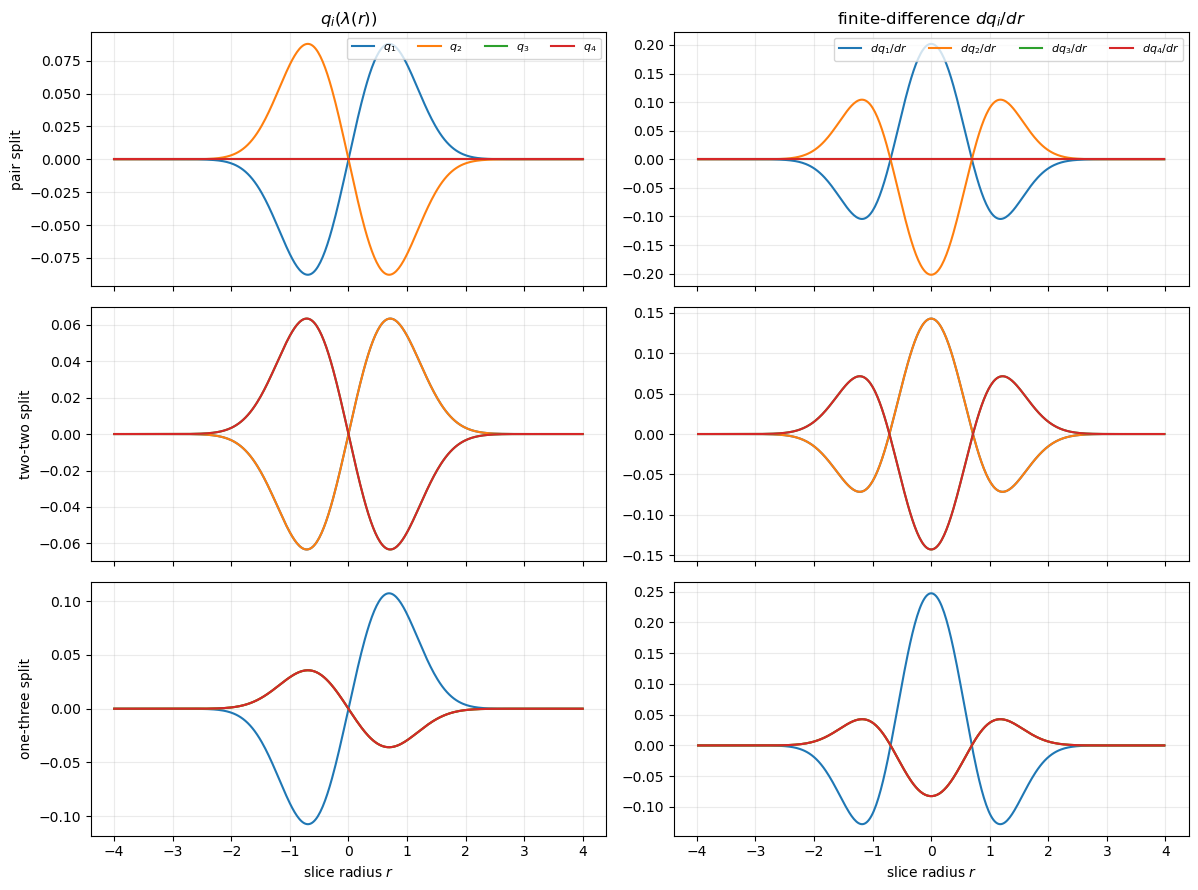

{'alpha': 1.6816117030757929,
 'cubic': 0.5338653705033293,
 'Chebyshev scale L': 3.5}

In [38]:
su4_final = sun_results["su4"]["history"][-1]
su4_alpha = su4_final["alpha"]
su4_cubic = su4_final["cubic"]
su4_scale = 3.5
su4_tail_eps = 1.0e-6

def normalize_direction(values):
    mean = sum(values) / len(values)
    centered = [value - mean for value in values]
    norm = math.sqrt(sum(value * value for value in centered))
    return [value / norm for value in centered]

def su4_conservative_action(lam):
    p2 = sum(value * value for value in lam)
    cubic_tail = sum((value * value + su4_tail_eps**2) ** 1.5 for value in lam)
    return su4_alpha * p2 + su4_cubic * cubic_tail

def su4_conservative_q(lam):
    mean = sum(lam) / len(lam)
    centered = [value - mean for value in lam]
    amplitude = math.exp(-0.5 * su4_conservative_action(centered))
    return [amplitude * value / su4_scale for value in centered]

su4_slice_directions = {
    "pair split": normalize_direction([1.0, -1.0, 0.0, 0.0]),
    "two-two split": normalize_direction([1.0, 1.0, -1.0, -1.0]),
    "one-three split": normalize_direction([3.0, -1.0, -1.0, -1.0]),
}
su4_r_values = [-4.0 + 8.0 * index / 400 for index in range(401)]

fig, axes = plt.subplots(
    len(su4_slice_directions),
    2,
    figsize=(12, 9),
    sharex=True,
)
for row, (label, direction) in enumerate(su4_slice_directions.items()):
    q_values = [
        su4_conservative_q([radius * value for value in direction])
        for radius in su4_r_values
    ]
    for component in range(4):
        component_values = [value[component] for value in q_values]
        derivative_values = [
            (component_values[index + 1] - component_values[index - 1])
            / (su4_r_values[index + 1] - su4_r_values[index - 1])
            for index in range(1, len(su4_r_values) - 1)
        ]
        axes[row, 0].plot(
            su4_r_values,
            component_values,
            label=fr"$q_{component + 1}$",
        )
        axes[row, 1].plot(
            su4_r_values[1:-1],
            derivative_values,
            label=fr"$dq_{component + 1}/dr$",
        )
    axes[row, 0].set_ylabel(label)
    axes[row, 0].grid(alpha=0.25)
    axes[row, 1].grid(alpha=0.25)

axes[0, 0].set_title(r"$q_i(\lambda(r))$")
axes[0, 1].set_title(r"finite-difference $dq_i/dr$")
axes[-1, 0].set_xlabel(r"slice radius $r$")
axes[-1, 1].set_xlabel(r"slice radius $r$")
axes[0, 0].legend(ncol=4, fontsize=8)
axes[0, 1].legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

{"alpha": su4_alpha, "cubic": su4_cubic, "Chebyshev scale L": su4_scale}


### SU(4) Conservative Baseline

The plot checks cross-grid stability of the current trusted SU(4) baseline. The Hellmann-Feynman diagnostic compares the saved central value of `Tr X^4` to a finite difference of independently trained `g \pm 0.02` runs.

### SU(4) Training Loss History

For this deterministic quadrature run, the training loss is the variational Rayleigh quotient \(E_\theta\). The first plot shows the saved energy history. The second plot shows \(\log_{10}(E_\theta-E_{\rm final})\), using a small floor only at the last point where the difference is zero by definition.

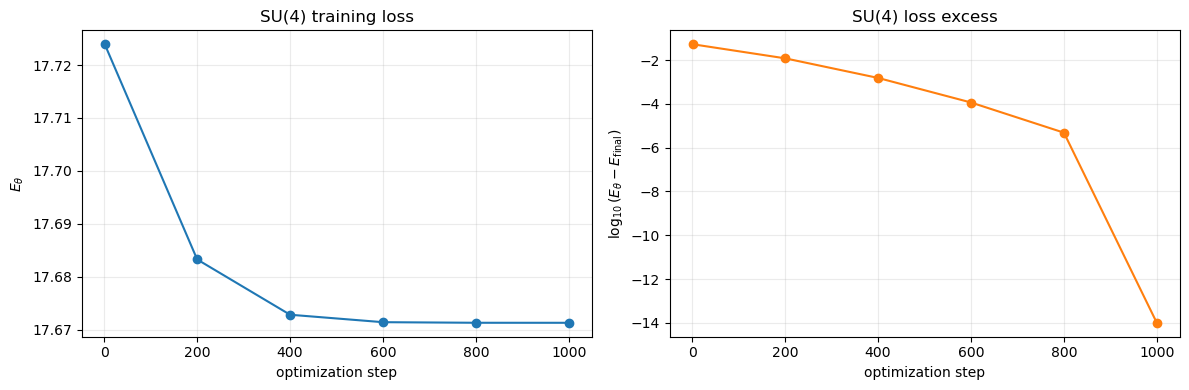

{'initial energy': 17.723923248432722,
 'final training energy': 17.671306083278612,
 'energy decrease': 0.05261716515411052,
 'saved history points': 6}

In [37]:
su4_history = sun_results["su4"]["history"]
su4_steps = [record["step"] for record in su4_history]
su4_loss = [record["energy"] for record in su4_history]
su4_loss_final = su4_loss[-1]
su4_loss_excess = [max(value - su4_loss_final, 1.0e-14) for value in su4_loss]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(su4_steps, su4_loss, marker="o")
axes[0].set_xlabel("optimization step")
axes[0].set_ylabel(r"$E_\theta$")
axes[0].set_title("SU(4) training loss")
axes[0].grid(alpha=0.25)

axes[1].plot(
    su4_steps,
    [math.log10(value) for value in su4_loss_excess],
    marker="o",
    color="tab:orange",
)
axes[1].set_xlabel("optimization step")
axes[1].set_ylabel(r"$\log_{10}(E_\theta-E_{\rm final})$")
axes[1].set_title("SU(4) loss excess")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

{
    "initial energy": su4_loss[0],
    "final training energy": su4_loss_final,
    "energy decrease": su4_loss[0] - su4_loss_final,
    "saved history points": len(su4_history),
}

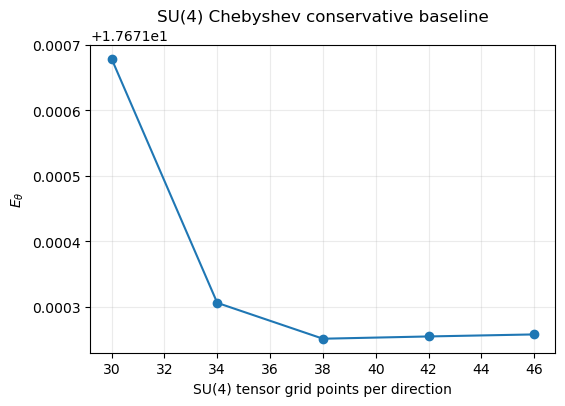

{'grid 42 energy': 17.671254775405174,
 'grid 42 virial residual': -0.0009001003488045001,
 'Hellmann-Feynman': {'delta_g': 0.02,
  'central_tr_x4': 4.8105785188834025,
  'finite_difference_derivative': 4.810702367595354,
  'error': -0.00012384871195170177}}

In [36]:
su4_evals = sun_results["su4"]["evaluations"]
su4_grids = [int(key) for key in su4_evals]
su4_energies = [su4_evals[str(grid)]["energy"] for grid in su4_grids]

plt.figure(figsize=(6, 4))
plt.plot(su4_grids, su4_energies, marker="o")
plt.xlabel("SU(4) tensor grid points per direction")
plt.ylabel(r"$E_{\theta}$")
plt.title("SU(4) Chebyshev conservative baseline")
plt.grid(alpha=0.25)
plt.show()

{
    "grid 42 energy": su4_evals["42"]["energy"],
    "grid 42 virial residual": su4_evals["42"]["virial_residual"],
    "Hellmann-Feynman": {
        key: value
        for key, value in sun_results["su4"]["hellmann_feynman"].items()
        if key not in ("minus", "plus")
    },
}

## Shared Flexible-Ansatz Monte Carlo

This section loads results from `scripts/run_sun_adjoint_vmc_benchmarks.py`. The important change is that SU(2) and SU(3) now use the same Chebyshev spectral-impurity ansatz and the same Sobol-Gaussian importance Monte Carlo estimator; the radial finite-difference answer is used only as an external benchmark. No training is performed in the notebook.


In [ ]:
SUN_VMC_RESULT_PATH = ROOT / "results" / "sun_adjoint_vmc_benchmarks.json"
if not SUN_VMC_RESULT_PATH.exists():
    raise FileNotFoundError(
        "Missing shared-ansatz VMC result file. Run from the repository root:\n"
        f"python scripts/run_sun_adjoint_vmc_benchmarks.py --output {SUN_VMC_RESULT_PATH}"
    )

sun_vmc_results = json.loads(SUN_VMC_RESULT_PATH.read_text())
{
    "shared_ansatz_config": sun_vmc_results["metadata"]["shared_ansatz_config"],
    "validation_summary": sun_vmc_results["validation_summary"],
}


### Monte Carlo Training Diagnostics

The plotted quantity is the sampled Dirichlet-form energy used for optimization on the training Sobol cloud. The independent energy and virial checks are shown below.


In [ ]:
plt.figure(figsize=(7, 4))
for label, payload in sun_vmc_results["runs"].items():
    history = payload["history"]
    plt.plot(
        [record["step"] for record in history],
        [record["surrogate_loss"] for record in history],
        marker="o",
        label=label.upper(),
    )
plt.xlabel("Monte Carlo optimization step")
plt.ylabel("sampled Dirichlet energy")
plt.title("Shared flexible Chebyshev ansatz MC loss")
plt.grid(alpha=0.25)
plt.legend()
plt.show()


### External Benchmark Comparison

Here the radial finite-difference energy is used only as a known answer for SU(2) and SU(3). The points are independent scrambled Sobol evaluations of the trained shared ansatz. The second panel shows the virial residual, which is the strict benchmark we want before moving this path to higher N.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for offset, (label, payload) in enumerate(sun_vmc_results["runs"].items()):
    evaluations = payload["evaluations"]
    combined = payload["combined_evaluation"]
    benchmark = combined.get("benchmark_energy")
    x = [offset + 0.08 * (i - 1) for i in range(len(evaluations))]
    energy_errors = [record["energy"] - benchmark for record in evaluations]
    virials = [record["virial_residual"] for record in evaluations]
    axes[0].plot(x, energy_errors, "o", label=label.upper())
    axes[1].plot(x, virials, "o", label=label.upper())
    axes[1].hlines(
        [sun_vmc_results["metadata"]["virial_abs_tol"], -sun_vmc_results["metadata"]["virial_abs_tol"]],
        offset - 0.18,
        offset + 0.18,
        colors="tab:gray",
        linestyles="dashed",
        linewidth=1,
    )
for ax in axes:
    ax.axhline(0.0, color="black", linewidth=1)
    ax.set_xticks(range(len(sun_vmc_results["runs"])), [key.upper() for key in sun_vmc_results["runs"]])
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$E_{\rm MC}-E_{\rm radial\ FD}$")
axes[0].set_title("Energy residual")
axes[1].set_ylabel(r"$2\langle T\rangle-\langle X\cdot\nabla V\rangle$")
axes[1].set_title("Virial residual")
axes[1].legend()
plt.tight_layout()
plt.show()

{
    label: payload["combined_evaluation"]
    for label, payload in sun_vmc_results["runs"].items()
}


# Current SU(4) Validation Results

This section loads the current saved validation runs from `scripts/run_sun_adjoint_vmc_benchmarks.py`. It is intentionally plot-focused and does not run training or tests inside the notebook. The nontrivial checks shown here are: small-\(N\) radial benchmarks, SU(4) odd/even sector comparison, ladder monotonicity versus independent validation, virial and ESS gates, Hellmann-Feynman, and the linear-to-neural bridge/refinement checkpoint.

In [5]:
SUN_CURRENT_PATHS = {
    "small_n": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su23_current_validated.json",
    "su4_odd_linear": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_linear_validated.json",
    "su4_odd_ladder": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_odd_ladder_validated.json",
    "su4_even_ladder": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_even_ladder_validated.json",
    "su4_neural_zero": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_linear_initialized_zero_validated.json",
    "su4_hf": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_linear_hf_validated.json",
    "su4_neural_one_step": ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_current_linear_initialized_one_step_validated.json",
}

missing = [path for path in SUN_CURRENT_PATHS.values() if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing current validation JSON files. Reproduce them with the commands in "
        "tex/Adjoint_QM_SU4_Implementation_Instructions.tex. Missing:\n"
        + "\n".join(str(path) for path in missing)
    )

sun_current = {
    name: json.loads(path.read_text())
    for name, path in SUN_CURRENT_PATHS.items()
}

{
    name: payload["validation_summary"]["all_checks_passed"]
    for name, payload in sun_current.items()
}

{'small_n': True,
 'su4_odd_linear': True,
 'su4_odd_ladder': True,
 'su4_even_ladder': True,
 'su4_neural_zero': True,
 'su4_hf': True,
 'su4_neural_one_step': True}

## Validation Gate Matrix

Each row is a saved run. Each column is a script-level validation gate. White entries would mark failed or missing gates. This is the first thing to inspect before interpreting any energy comparison.

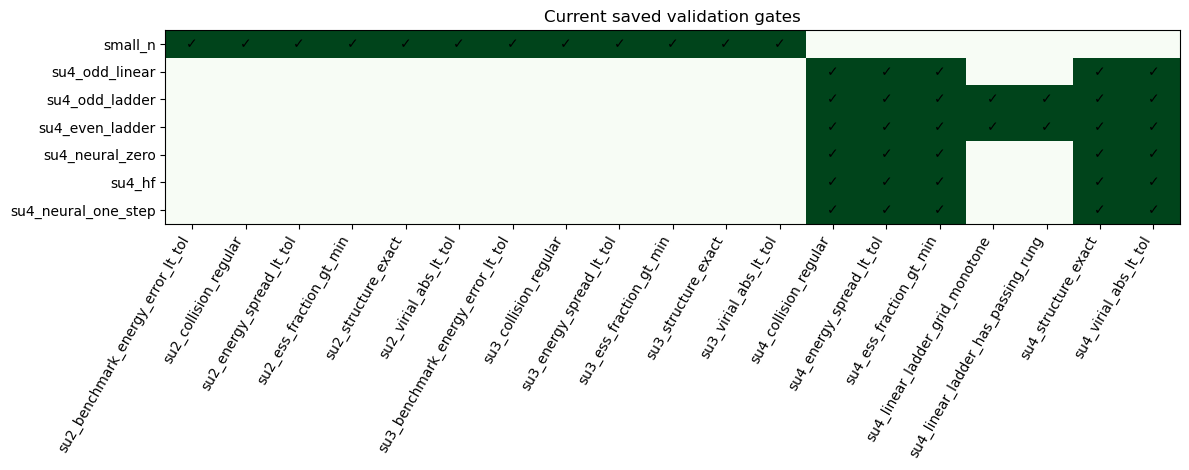

In [6]:
gate_names = sorted({
    check
    for payload in sun_current.values()
    for check in payload["validation_summary"]["checks"]
})
run_names = list(sun_current)
gate_matrix = [
    [1 if sun_current[run]["validation_summary"]["checks"].get(gate, False) else 0 for gate in gate_names]
    for run in run_names
]

fig, ax = plt.subplots(figsize=(12, 4.8))
im = ax.imshow(gate_matrix, vmin=0, vmax=1, cmap="Greens", aspect="auto")
ax.set_xticks(range(len(gate_names)), gate_names, rotation=60, ha="right")
ax.set_yticks(range(len(run_names)), run_names)
for row, run in enumerate(run_names):
    for col, gate in enumerate(gate_names):
        present = gate in sun_current[run]["validation_summary"]["checks"]
        text = "✓" if gate_matrix[row][col] else ("×" if present else "")
        ax.text(col, row, text, ha="center", va="center", fontsize=10)
ax.set_title("Current saved validation gates")
plt.tight_layout()
plt.show()

## Small-N External Benchmark Errors

The SU(2) and SU(3) entries use the same flexible Chebyshev/Sobol Monte Carlo code path as SU(4), but they can still be compared to independent radial finite-difference benchmarks. Passing these checks is evidence that the shared ansatz and estimator are not only self-consistent.

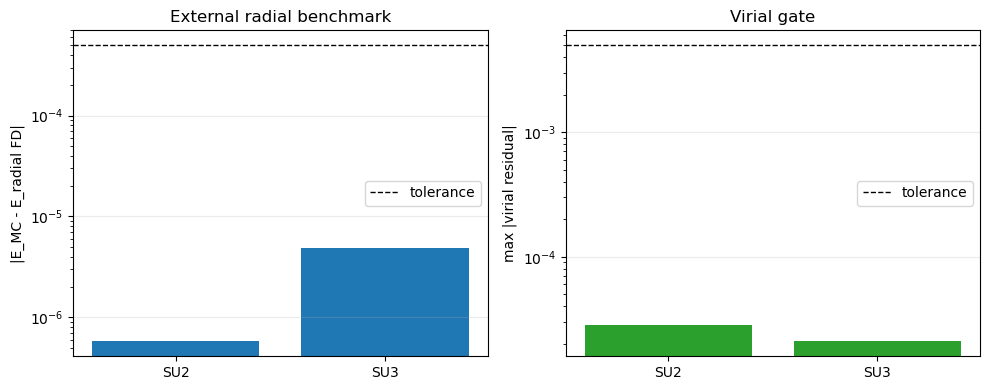

In [7]:
small_n = sun_current["small_n"]["runs"]
small_labels = ["su2", "su3"]
small_errors = [
    abs(small_n[label]["candidate_summaries"][small_n[label]["selected_candidate"]]["combined_evaluation"]["energy_error"])
    for label in small_labels
]
small_virials = [
    small_n[label]["candidate_summaries"][small_n[label]["selected_candidate"]]["combined_evaluation"]["virial_residual_abs_max"]
    for label in small_labels
]
energy_tol = sun_current["small_n"]["metadata"]["energy_abs_tol"]
virial_tol = sun_current["small_n"]["metadata"]["virial_abs_tol"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar([label.upper() for label in small_labels], small_errors, color="tab:blue")
axes[0].axhline(energy_tol, color="black", linestyle="--", linewidth=1, label="tolerance")
axes[0].set_yscale("log")
axes[0].set_ylabel("|E_MC - E_radial FD|")
axes[0].set_title("External radial benchmark")
axes[0].legend()
axes[0].grid(alpha=0.25, axis="y")

axes[1].bar([label.upper() for label in small_labels], small_virials, color="tab:green")
axes[1].axhline(virial_tol, color="black", linestyle="--", linewidth=1, label="tolerance")
axes[1].set_yscale("log")
axes[1].set_ylabel("max |virial residual|")
axes[1].set_title("Virial gate")
axes[1].legend()
axes[1].grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

## SU(4) Odd/Even Sector Energy Comparison

The odd sector contains the lower accepted adjoint candidate in the tested sectors. Error bars below show half the spread across independent Sobol evaluation replicas, not a rigorous statistical error bar.

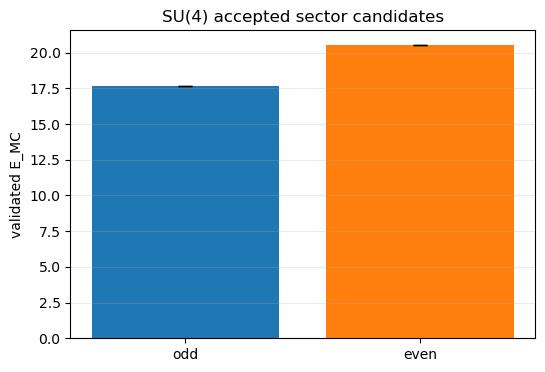

{'odd selected': 'linear_impurity_after_envelope',
 'even selected': 'envelope_quadrature_lbfgs',
 'even minus odd energy': 2.870261889380977}

In [8]:
def selected_summary(payload, run="su4"):
    run_payload = payload["runs"][run]
    name = run_payload["selected_candidate"]
    candidate = run_payload["candidate_summaries"][name]
    return name, candidate["combined_evaluation"]

odd_name, odd_combined = selected_summary(sun_current["su4_odd_linear"])
even_name, even_combined = selected_summary(sun_current["su4_even_ladder"])
sector_labels = ["odd", "even"]
sector_energies = [odd_combined["energy_mean"], even_combined["energy_mean"]]
sector_spreads = [
    0.5 * odd_combined["energy_spread_independent_runs"],
    0.5 * even_combined["energy_spread_independent_runs"],
]

plt.figure(figsize=(6, 4))
plt.bar(sector_labels, sector_energies, yerr=sector_spreads, capsize=5, color=["tab:blue", "tab:orange"])
plt.ylabel("validated E_MC")
plt.title("SU(4) accepted sector candidates")
plt.grid(alpha=0.25, axis="y")
plt.show()

{
    "odd selected": odd_name,
    "even selected": even_name,
    "even minus odd energy": even_combined["energy_mean"] - odd_combined["energy_mean"],
}

## SU(4) Acceptance Margins

For virial residual and independent energy spread, values below one pass. For ESS, values above one pass. These are the hard validation gates used before selecting a candidate.

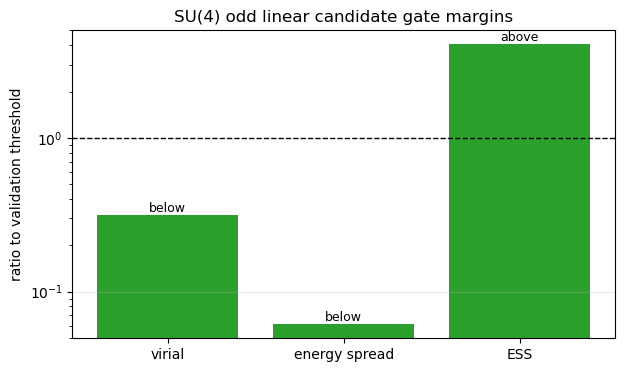

In [9]:
su4_meta = sun_current["su4_odd_linear"]["metadata"]
margin_labels = ["virial", "energy spread", "ESS"]
odd_margins = [
    odd_combined["virial_residual_abs_max"] / su4_meta["virial_abs_tol"],
    odd_combined["energy_spread_independent_runs"] / su4_meta["energy_spread_abs_tol"],
    odd_combined["min_effective_sample_size_fraction"] / su4_meta["min_ess_fraction"],
]
pass_direction = ["below", "below", "above"]
colors = ["tab:green" if value < 1 else "tab:red" for value in odd_margins[:2]] + ["tab:green" if odd_margins[2] > 1 else "tab:red"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(margin_labels, odd_margins, color=colors)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)
ax.set_yscale("log")
ax.set_ylabel("ratio to validation threshold")
ax.set_title("SU(4) odd linear candidate gate margins")
for idx, (value, direction) in enumerate(zip(odd_margins, pass_direction)):
    ax.text(idx, value, direction, ha="center", va="bottom", fontsize=9)
ax.grid(alpha=0.25, axis="y")
plt.show()

## Linear Impurity Ladders

The deterministic grid Ritz energies are monotone for nested bases, as required by the finite-dimensional generalized eigenproblem. Independent validation is stricter: some rungs lower the grid energy but fail virial gates, so they are not accepted.

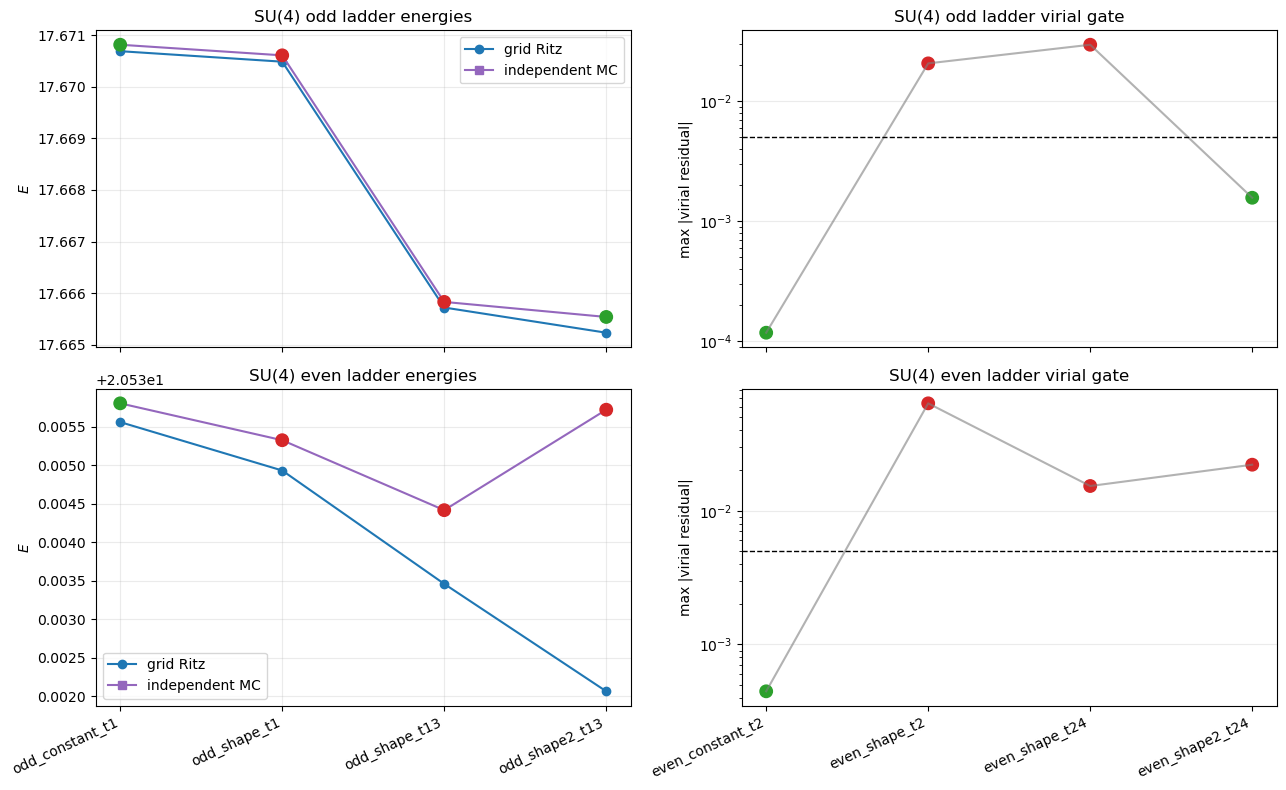

{'odd grid monotone': True,
 'odd lowest passing rung': 'linear_ladder_odd_shape_quadratic_t13',
 'even grid monotone': True,
 'even lowest passing rung': 'linear_ladder_even_constant_t2'}

In [10]:
def short_rung_name(name):
    return name.replace("linear_ladder_", "").replace("shape_quadratic", "shape2")

odd_ladder = sun_current["su4_odd_ladder"]["runs"]["su4"]["linear_ladder_summary"]
even_ladder = sun_current["su4_even_ladder"]["runs"]["su4"]["linear_ladder_summary"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex="col")
for row, (title, ladder) in enumerate([("odd", odd_ladder), ("even", even_ladder)]):
    x = list(range(len(ladder["rung_names"])))
    labels = [short_rung_name(name) for name in ladder["rung_names"]]
    colors = ["tab:green" if passed else "tab:red" for passed in ladder["passes_validation_gates"]]

    axes[row, 0].plot(x, ladder["grid_energies"], marker="o", color="tab:blue", label="grid Ritz")
    axes[row, 0].plot(x, ladder["independent_energy_means"], marker="s", color="tab:purple", label="independent MC")
    axes[row, 0].scatter(x, ladder["independent_energy_means"], c=colors, s=80, zorder=3)
    axes[row, 0].set_ylabel(r"$E$")
    axes[row, 0].set_title(f"SU(4) {title} ladder energies")
    axes[row, 0].grid(alpha=0.25)
    axes[row, 0].legend()

    axes[row, 1].scatter(x, ladder["independent_virial_abs_max"], c=colors, s=80)
    axes[row, 1].plot(x, ladder["independent_virial_abs_max"], color="tab:gray", alpha=0.6)
    axes[row, 1].axhline(su4_meta["virial_abs_tol"], color="black", linestyle="--", linewidth=1)
    axes[row, 1].set_yscale("log")
    axes[row, 1].set_ylabel("max |virial residual|")
    axes[row, 1].set_title(f"SU(4) {title} ladder virial gate")
    axes[row, 1].grid(alpha=0.25, axis="y")
    axes[row, 1].set_xticks(x, labels, rotation=25, ha="right")

axes[1, 0].set_xticks(range(len(odd_ladder["rung_names"])), [short_rung_name(name) for name in odd_ladder["rung_names"]], rotation=25, ha="right")
plt.tight_layout()
plt.show()

{
    "odd grid monotone": odd_ladder["grid_energy_monotone_nonincreasing"],
    "odd lowest passing rung": odd_ladder["lowest_passing_rung"],
    "even grid monotone": even_ladder["grid_energy_monotone_nonincreasing"],
    "even lowest passing rung": even_ladder["lowest_passing_rung"],
}

## Hellmann-Feynman and Neural-Bridge Checks

The Hellmann-Feynman plot compares the finite-difference derivative \(dE/dg\) to \(\langle\operatorname{Tr}X^4\rangle\). The neural-bridge plot shows why the optional neural refinement remains conservative: a one-step trained checkpoint failed the single-cloud virial gate, so the script restored the exact linear initialization.

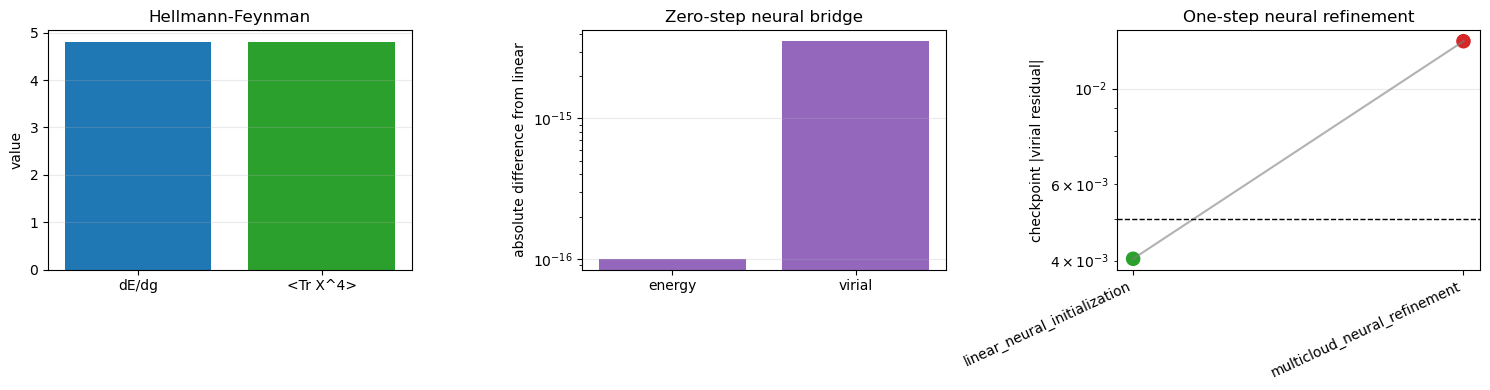

{'HF error': -0.00027428531254614086,
 'same selected branch at shifted couplings': True,
 'zero-step neural energy difference': 0.0,
 'one-step restored checkpoint': 'linear_initialization',
 'one-step final neural passes gates': True}

In [11]:
hf = sun_current["su4_hf"]["runs"]["su4"]["hellmann_feynman"]
zero_run = sun_current["su4_neural_zero"]["runs"]["su4"]
one_run = sun_current["su4_neural_one_step"]["runs"]["su4"]
zero_linear = zero_run["candidate_summaries"]["linear_impurity_after_envelope"]["combined_evaluation"]
zero_neural = zero_run["candidate_summaries"]["linear_initialized_neural_full_head"]["combined_evaluation"]
one_neural = one_run["candidate_summaries"]["linear_initialized_neural_full_head"]
checkpoints = one_neural["training"]["neural_refinement_checkpoint_history"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(["dE/dg", "<Tr X^4>"], [hf["finite_difference_derivative"], hf["central_tr_x4"]], color=["tab:blue", "tab:green"])
axes[0].set_title("Hellmann-Feynman")
axes[0].set_ylabel("value")
axes[0].grid(alpha=0.25, axis="y")

bridge_values = [
    abs(zero_neural["energy_mean"] - zero_linear["energy_mean"]),
    abs(zero_neural["virial_residual_abs_max"] - zero_linear["virial_residual_abs_max"]),
]
axes[1].bar(["energy", "virial"], [max(v, 1.0e-16) for v in bridge_values], color="tab:purple")
axes[1].set_yscale("log")
axes[1].set_title("Zero-step neural bridge")
axes[1].set_ylabel("absolute difference from linear")
axes[1].grid(alpha=0.25, axis="y")

checkpoint_x = list(range(len(checkpoints)))
checkpoint_labels = [record["stage"].replace("_checkpoint", "") for record in checkpoints]
checkpoint_virials = [abs(record["virial_residual"]) for record in checkpoints]
checkpoint_colors = ["tab:green" if record["single_cloud_checkpoint_passed"] else "tab:red" for record in checkpoints]
axes[2].scatter(checkpoint_x, checkpoint_virials, c=checkpoint_colors, s=90)
axes[2].plot(checkpoint_x, checkpoint_virials, color="tab:gray", alpha=0.6)
axes[2].axhline(su4_meta["virial_abs_tol"], color="black", linestyle="--", linewidth=1)
axes[2].set_yscale("log")
axes[2].set_xticks(checkpoint_x, checkpoint_labels, rotation=25, ha="right")
axes[2].set_ylabel("checkpoint |virial residual|")
axes[2].set_title("One-step neural refinement")
axes[2].grid(alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

{
    "HF error": hf["error"],
    "same selected branch at shifted couplings": hf["same_selected_candidate"],
    "zero-step neural energy difference": zero_neural["energy_mean"] - zero_linear["energy_mean"],
    "one-step restored checkpoint": one_neural["training"]["neural_refinement_restored_checkpoint_source"],
    "one-step final neural passes gates": one_neural["passes_validation_gates"],
}

## SU(4) Neural Training History

This plot shows the saved training data for the flexible SU(4) neural candidate. The long curve is the fixed-proposal Adam neural run; it lowers the sampled training energy but fails the independent virial validation, so it is not accepted as the ground state. The checkpoint panel shows the current linear-initialized neural refinement path: the trained checkpoint fails the single-cloud virial gate and the script restores the linear initialization.

In [ ]:
SU4_NEURAL_TRAINING_PATH = ROOT / "results" / "sun_adjoint_vmc_benchmarks_su4_linear_impurity_validated.json"
if SU4_NEURAL_TRAINING_PATH.exists():
    su4_training_payload = json.loads(SU4_NEURAL_TRAINING_PATH.read_text())
    su4_training_source = SU4_NEURAL_TRAINING_PATH.name
else:
    su4_training_payload = sun_current["su4_neural_one_step"]
    su4_training_source = SUN_CURRENT_PATHS["su4_neural_one_step"].name

su4_training_run = su4_training_payload["runs"]["su4"]

def full_candidate(run_payload, name):
    for candidate in run_payload["candidates"]:
        if candidate["name"] == name:
            return candidate
    raise KeyError(name)

adam_candidate = full_candidate(su4_training_run, "importance_adam_full_flexible")
adam_history = adam_candidate["history"]
adam_steps = [record["step"] for record in adam_history]
adam_energy = [record["energy"] for record in adam_history]
adam_local_std = [record["local_energy_std"] for record in adam_history]
adam_alpha = [record["alpha"] for record in adam_history]
adam_cubic = [record["cubic"] for record in adam_history]
adam_radial = [record["radial"] for record in adam_history]
adam_angular = [record["angular"] for record in adam_history]
adam_potential = [record["potential"] for record in adam_history]

accepted_energy = odd_combined["energy_mean"]
energy_excess = [max(energy - accepted_energy, 1.0e-12) for energy in adam_energy]

one_step_candidate = full_candidate(one_run, "linear_initialized_neural_full_head")
refine_history = one_step_candidate["history"]
checkpoint_history = one_step_candidate["training"]["neural_refinement_checkpoint_history"]
checkpoint_steps = [record["step"] for record in checkpoint_history]
checkpoint_virial = [abs(record["virial_residual"]) for record in checkpoint_history]
checkpoint_colors = ["tab:green" if record["single_cloud_checkpoint_passed"] else "tab:red" for record in checkpoint_history]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

axes[0, 0].plot(adam_steps, adam_energy, marker="o", label="training cloud energy")
axes[0, 0].axhline(accepted_energy, color="black", linestyle="--", linewidth=1, label="accepted linear energy")
axes[0, 0].set_xlabel("Adam step")
axes[0, 0].set_ylabel("energy")
axes[0, 0].set_title("Flexible neural Adam training")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

axes[0, 1].plot(adam_steps, [math.log10(value) for value in energy_excess], marker="o", color="tab:orange")
axes[0, 1].set_xlabel("Adam step")
axes[0, 1].set_ylabel("log10(training E - accepted E)")
axes[0, 1].set_title("Training-energy excess")
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(adam_steps, adam_radial, marker="o", label="radial kinetic")
axes[1, 0].plot(adam_steps, adam_angular, marker="o", label="angular kinetic")
axes[1, 0].plot(adam_steps, adam_potential, marker="o", label="potential")
axes[1, 0].plot(adam_steps, adam_local_std, marker="o", label="local energy std")
axes[1, 0].set_xlabel("Adam step")
axes[1, 0].set_ylabel("value")
axes[1, 0].set_title("Training components")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot(adam_steps, adam_alpha, marker="o", label="alpha")
axes[1, 1].plot(adam_steps, adam_cubic, marker="o", label="quartic tail coeff")
axes[1, 1].scatter(checkpoint_steps, checkpoint_virial, c=checkpoint_colors, marker="s", s=70, label="linear-init checkpoint |virial|")
axes[1, 1].axhline(su4_meta["virial_abs_tol"], color="black", linestyle="--", linewidth=1, label="virial tolerance")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel("step")
axes[1, 1].set_ylabel("parameter value / checkpoint residual")
axes[1, 1].set_title("Parameters and refinement checkpoint")
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

{
    "training source": su4_training_source,
    "adam candidate passes final gates": adam_candidate["passes_validation_gates"],
    "adam independent virial max": adam_candidate["combined_evaluation"]["virial_residual_abs_max"],
    "accepted linear energy": accepted_energy,
    "final Adam training energy": adam_energy[-1],
    "one-step restored checkpoint": one_step_candidate["training"]["neural_refinement_restored_checkpoint_source"],
}